# Importações

In [ ]:
!pip install optuna

In [ ]:
import numpy as np
from numpy.linalg import LinAlgError
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn import decomposition
from skimage.util import random_noise
from sklearn.decomposition import PCA, KernelPCA
import pandas as pd
import optuna
import optuna.logging
from sklearn.preprocessing import StandardScaler
import warnings
from scipy.linalg import LinAlgWarning
from sklearn.model_selection import train_test_split

# Modelos Optuna - Max. PSNR Min. AIC

## Kernel PCA

In [ ]:
# Usando Optuna para encontrar a melhor combinação de hiperparâmetros para imagens com um ruído em específico
def objective_aic(trial, faces, noise):
  # Ensure faces is a NumPy array and convert to float64 before applying random_noise
  faces_array = np.array(faces, dtype=np.float64)
  facesNoise = random_noise(faces_array, mode=noise)

  kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'cosine', 'sigmoid'])
  gamma = trial.suggest_float('gamma', 1e-5, 10, log=True)
  degree = trial.suggest_int('degree', 2, 6)
  coef0 = trial.suggest_int('coef0', 0, 10)
  components = trial.suggest_int('components', 2, 200)
  alpha = trial.suggest_float('alpha', 1e-5, 10, log=True)

  try:
    kernel_pca = KernelPCA(n_components=components, kernel=kernel, gamma=gamma, degree=degree, coef0=coef0,
                          fit_inverse_transform=True, alpha=alpha)
    _ = kernel_pca.fit(facesNoise)
    facesReconstructed = kernel_pca.inverse_transform(kernel_pca.transform(facesNoise))

    max_I = faces_array.max()
    mse_reconstructed = np.mean((faces_array - facesReconstructed) ** 2)
    if mse_reconstructed == 0:
            return 100.0
    psnr_reconstructed = 10 * np.log10(max_I ** 2 / mse_reconstructed)
    aic = 2 * components - 2 * np.log(psnr_reconstructed)
    trial.set_user_attr("psnr", psnr_reconstructed)

    return aic
  except:
    # Return a very large value to indicate a failed trial for minimization
    trial.set_user_attr("psnr", 0) # Set a default PSNR in case of exception
    return 1e9

In [ ]:
# Usando Optuna para encontrar a melhor combinação de hiperparâmetros para imagens com um ruído em específico
def objective_psnr(trial, faces, noise):
  # Ensure faces is a NumPy array and convert to float64 before applying random_noise
  faces_array = np.array(faces, dtype=np.float64)
  facesNoise = random_noise(faces_array, mode=noise)

  kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'cosine', 'sigmoid'])
  gamma = trial.suggest_float('gamma', 1e-5, 10, log=True)
  degree = trial.suggest_int('degree', 2, 6)
  coef0 = trial.suggest_int('coef0', 0, 10)
  components = trial.suggest_int('components', 2, 200)
  alpha = trial.suggest_float('alpha', 1e-5, 10, log=True)

  try:
    kernel_pca = KernelPCA(n_components=components, kernel=kernel, gamma=gamma, degree=degree, coef0=coef0,
                          fit_inverse_transform=True, alpha=alpha)
    _ = kernel_pca.fit(facesNoise)
    facesReconstructed = kernel_pca.inverse_transform(kernel_pca.transform(facesNoise))

    max_I = faces_array.max()
    mse_reconstructed = np.mean((faces_array - facesReconstructed) ** 2)
    if mse_reconstructed == 0:
            return 100.0
    psnr_reconstructed = 10 * np.log10(max_I ** 2 / mse_reconstructed)

    return psnr_reconstructed
  except:
    return 0

In [ ]:
olivetti_faces = fetch_olivetti_faces()

X = olivetti_faces.data

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [ ]:
noises = ['gaussian', 'localvar', 'salt', 'pepper', 's&p', 'speckle', 'poisson']

warnings.filterwarnings("ignore", category=LinAlgWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
for noise in noises:
    study_aic = optuna.create_study(direction='minimize')
    study_psnr = optuna.create_study(direction='maximize')
    study_aic.optimize(lambda trial: objective_aic(trial, X_train, noise), n_trials=200)
    study_psnr.optimize(lambda trial: objective_psnr(trial, X_train, noise), n_trials=200)
    print(f"\nOtimização do ruído: {noise}")
    print(f"Melhor valor (PSNR médio): {study_psnr.best_value}")
    print(f"Melhor valor (AIC): {study_aic.best_value}")
    print("Modelo PSNR")
    for key, value in study_psnr.best_params.items():
        print(f"  {key}: {value}")
    print("Modelo AIC")
    psnr_aic = study_aic.best_trial.user_attrs["psnr"]
    print(f"  PSNR: {psnr_aic}")
    for key, value in study_aic.best_params.items():
        print(f"  {key}: {value}")
    print("\n")


Otimização do ruído: gaussian
Melhor valor (PSNR médio): 24.77297153153204
Melhor valor (AIC): -1.9166000442647766
Modelo PSNR
  kernel: poly
  gamma: 0.0016672651816838284
  degree: 2
  coef0: 7
  components: 176
  alpha: 0.08226252421766829
Modelo AIC
  PSNR: 19.26519349967722
  kernel: poly
  gamma: 0.007372710433401995
  degree: 2
  coef0: 4
  components: 2
  alpha: 0.34871164010403904



Otimização do ruído: localvar
Melhor valor (PSNR médio): 24.716758587717926
Melhor valor (AIC): 0.8108543009538964
Modelo PSNR
  kernel: rbf
  gamma: 0.001553085210773272
  degree: 6
  coef0: 2
  components: 146
  alpha: 0.0009100719488030337
Modelo AIC
  PSNR: 4.926224383546777
  kernel: linear
  gamma: 0.6479802503865428
  degree: 3
  coef0: 4
  components: 2
  alpha: 5.535202162847551



Otimização do ruído: salt
Melhor valor (PSNR médio): 23.397788612816704
Melhor valor (AIC): -1.90319821952479
Modelo PSNR
  kernel: poly
  gamma: 3.6087376551120134e-05
  degree: 2
  coef0: 8
  components: 92


## PCA

In [ ]:
# Usando Optuna para encontrar a melhor combinação de hiperparâmetros para imagens com um ruído em específico
def objective_pca_aic(trial, faces, noise):
  # Ensure faces is a NumPy array and convert to float64 before applying random_noise
  faces_array = np.array(faces, dtype=np.float64)
  facesNoise = random_noise(faces_array, mode=noise)

  components = trial.suggest_int('components', 2, 200)

  try:
    pca = PCA(n_components=components)
    pca.fit(facesNoise)
    faces_reconstructed_pca = pca.inverse_transform(pca.transform(facesNoise))

    max_I = faces_array.max()
    mse_reconstructed = np.mean((faces_array - faces_reconstructed_pca) ** 2)
    if mse_reconstructed == 0:
            return 100.0
    psnr_reconstructed = 10 * np.log10(max_I ** 2 / mse_reconstructed)
    aic = 2 * components - 2 * np.log(psnr_reconstructed)
    trial.set_user_attr("psnr", psnr_reconstructed)

    return aic
  except:
    # Return a very large value to indicate a failed trial for minimization
    trial.set_user_attr("psnr", 0) # Set a default PSNR in case of exception
    return 1e9

In [ ]:
# Usando Optuna para encontrar a melhor combinação de hiperparâmetros para imagens com um ruído em específico
def objective_pca_psnr(trial, faces, noise):
  # Ensure faces is a NumPy array and convert to float64 before applying random_noise
  faces_array = np.array(faces, dtype=np.float64)
  facesNoise = random_noise(faces_array, mode=noise)

  components = trial.suggest_int('components', 2, 200)

  try:
    pca = PCA(n_components=components)
    pca.fit(facesNoise)
    faces_reconstructed_pca = pca.inverse_transform(pca.transform(facesNoise))

    max_I = faces_array.max()
    mse_reconstructed = np.mean((faces_array - faces_reconstructed_pca) ** 2)
    if mse_reconstructed == 0:
            return 100.0
    psnr_reconstructed = 10 * np.log10(max_I ** 2 / mse_reconstructed)

    return psnr_reconstructed
  except:
    return 0

In [ ]:
noises = ['gaussian', 'localvar', 'salt', 'pepper', 's&p', 'speckle', 'poisson']

warnings.filterwarnings("ignore", category=LinAlgWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
for noise in noises:
    study_aic = optuna.create_study(direction='minimize')
    study_psnr = optuna.create_study(direction='maximize')
    study_aic.optimize(lambda trial: objective_pca_aic(trial, X_train, noise), n_trials=200)
    study_psnr.optimize(lambda trial: objective_pca_psnr(trial, X_train, noise), n_trials=200)
    print(f"\nOtimização do ruído: {noise}")
    print(f"Melhor valor (PSNR médio): {study_psnr.best_value}")
    print(f"Melhor valor (AIC): {study_aic.best_value}")
    print("Modelo PSNR")
    for key, value in study_psnr.best_params.items():
        print(f"  {key}: {value}")
    print("Modelo AIC")
    psnr_aic = study_aic.best_trial.user_attrs["psnr"]
    print(f"  PSNR: {psnr_aic}")
    for key, value in study_aic.best_params.items():
        print(f"  {key}: {value}")
    print("\n")


Otimização do ruído: gaussian
Melhor valor (PSNR médio): 23.74787203948521
Melhor valor (AIC): -1.9072025961709214
Modelo PSNR
  components: 48
Modelo AIC
  PSNR: 19.174884007557125
  components: 2



Otimização do ruído: localvar
Melhor valor (PSNR médio): 23.745904727406405
Melhor valor (AIC): -1.90724495125687
Modelo PSNR
  components: 49
Modelo AIC
  PSNR: 19.175290088787115
  components: 2



Otimização do ruído: salt
Melhor valor (PSNR médio): 22.82882592668042
Melhor valor (AIC): -1.8863992462005639
Modelo PSNR
  components: 39
Modelo AIC
  PSNR: 18.97646682074947
  components: 2



Otimização do ruído: pepper
Melhor valor (PSNR médio): 22.18368128106364
Melhor valor (AIC): -1.876904969367974
Modelo PSNR
  components: 30
Modelo AIC
  PSNR: 18.88659638856125
  components: 2



Otimização do ruído: s&p
Melhor valor (PSNR médio): 22.969353849017477
Melhor valor (AIC): -1.90388890561265
Modelo PSNR
  components: 31
Modelo AIC
  PSNR: 19.143140495816706
  components: 2



Otimização

# Variação de Ruído

Iniciando a análise de PCA e Kernel PCA...
Dataset Olivetti faces carregado. Shape: (400, 4096)
Valor máximo de pixel (Max_I) para PSNR: 1.0
Níveis de ruído (variância) a serem testados: [0.01, 0.05, 0.1, 0.2, 0.4, 0.8]

--- Processando nível de ruído (var): 0.01 ---
  PCA (n=53): MSE=0.003972, PSNR=24.010080 (Tempo: 1.00s)
  KPCA (n=148, k=rbf): MSE=0.003152, PSNR=25.013943 (Tempo: 0.76s)

--- Processando nível de ruído (var): 0.05 ---
  PCA (n=53): MSE=0.011053, PSNR=19.565374 (Tempo: 0.76s)
  KPCA (n=148, k=rbf): MSE=0.014096, PSNR=18.509004 (Tempo: 0.48s)

--- Processando nível de ruído (var): 0.1 ---
  PCA (n=53): MSE=0.018147, PSNR=17.411995 (Tempo: 0.39s)
  KPCA (n=148, k=rbf): MSE=0.027309, PSNR=15.636889 (Tempo: 0.55s)

--- Processando nível de ruído (var): 0.2 ---
  PCA (n=53): MSE=0.028008, PSNR=15.527166 (Tempo: 0.48s)
  KPCA (n=148, k=rbf): MSE=0.045595, PSNR=13.410849 (Tempo: 0.52s)

--- Processando nível de ruído (var): 0.4 ---
  PCA (n=53): MSE=0.039097, PSNR=14.078585 

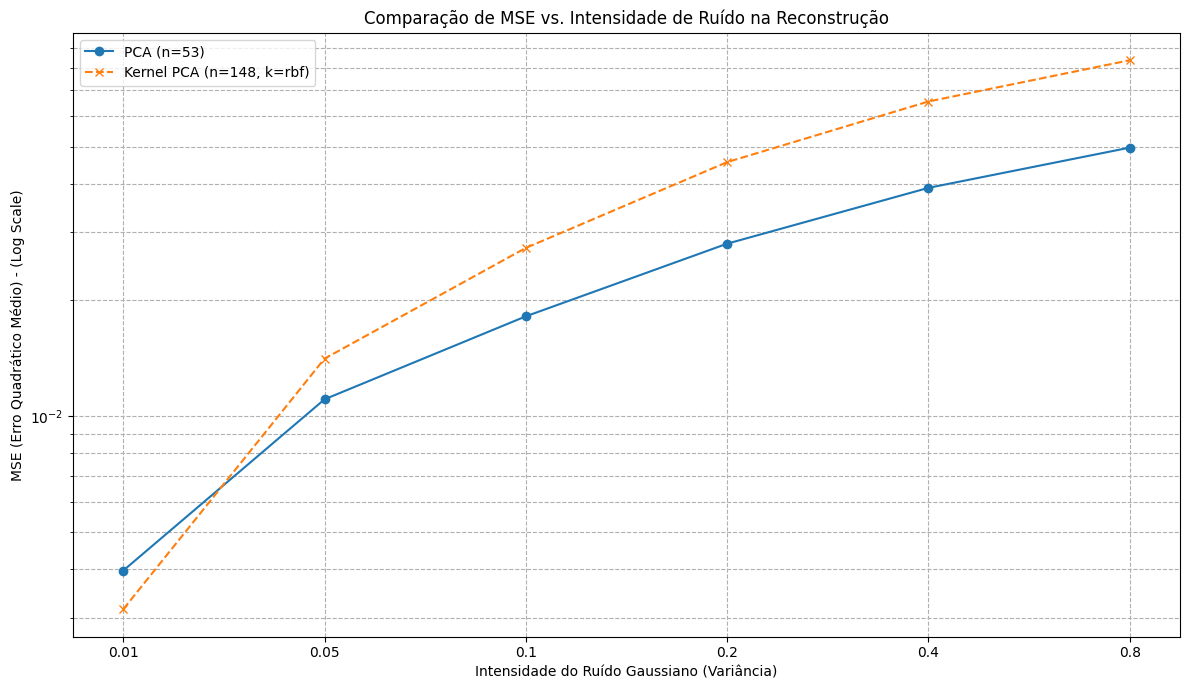

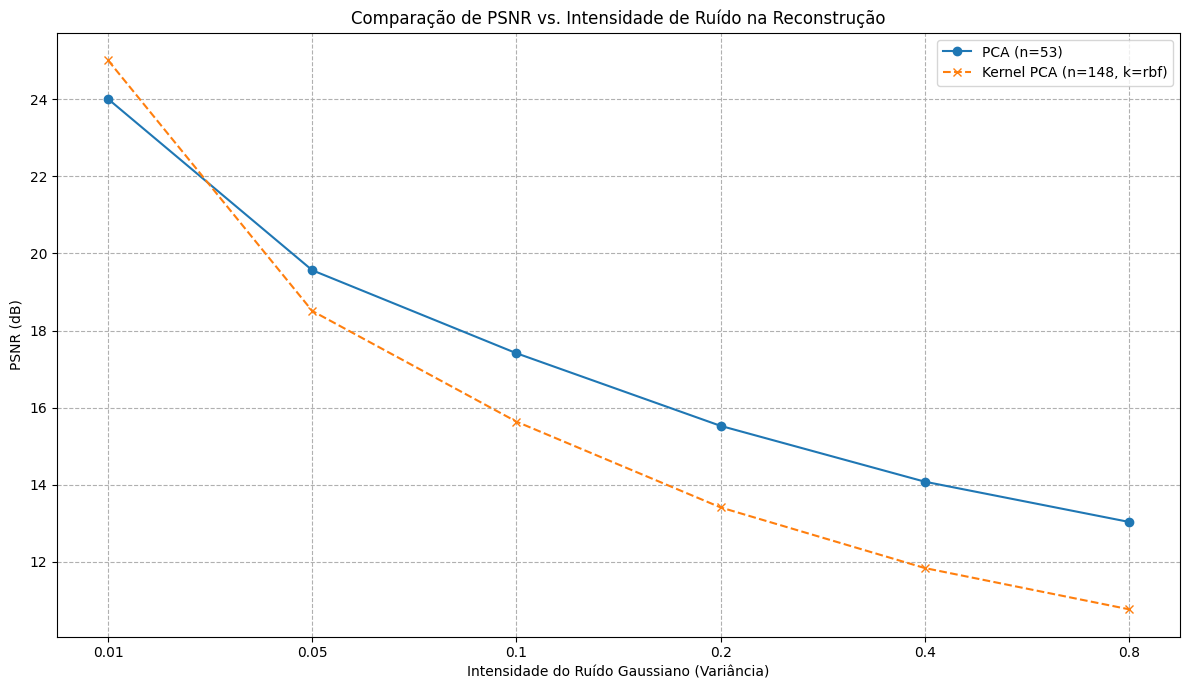

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA, KernelPCA
from skimage.util import random_noise
import warnings
import time

# Suprimir warnings que podem aparecer, por exemplo, do random_noise
warnings.filterwarnings('ignore')

print("Iniciando a análise de PCA e Kernel PCA...")

# 1. Carregar o dataset
try:
    # 'data_home' especifica um cache local para evitar downloads repetidos
    olivetti_faces = fetch_olivetti_faces(data_home='./scikit_learn_data')
    faces_array = olivetti_faces.data
    n_samples, n_features = faces_array.shape
    print(f"Dataset Olivetti faces carregado. Shape: {faces_array.shape}")

    # Calcular o valor máximo do pixel (para o PSNR)
    # Os dados já estão normalizados (float64 entre 0 e 1)
    max_I = faces_array.max()
    if max_I == 0:
        max_I = 1.0 # Evitar divisão por zero
    print(f"Valor máximo de pixel (Max_I) para PSNR: {max_I}")

except Exception as e:
    print(f"Erro ao carregar o dataset Olivetti faces: {e}")
    print("Verifique sua conexão com a internet ou o caminho do dataset.")
    exit()

# 2. Definir parâmetros
# Níveis de ruído (variância do ruído Gaussiano)
noise_levels = sorted([0.05, 0.01, 0.1, 0.2, 0.4, 0.8])
print(f"Níveis de ruído (variância) a serem testados: {noise_levels}")

# Parâmetros do Kernel PCA
kpca_params = {
    'n_components': 148,
    'kernel': 'rbf',
    'gamma': 0.000239,
    'alpha': 0.0000212,
    'fit_inverse_transform': True  # Essencial para reconstrução
}

# Parâmetros do PCA
pca_n_components = 53

# 3. Listas para armazenar resultados
results_mse_pca = []
results_psnr_pca = []
results_mse_kpca = []
results_psnr_kpca = []

# 4. Iterar sobre os níveis de ruído
for noise_var in noise_levels:
    print(f"\n--- Processando nível de ruído (var): {noise_var} ---")

    # a. Aplicar ruído gaussiano
    # O parâmetro 'var' em random_noise é a variância do ruído
    # 'clip=True' garante que os valores permaneçam entre [0, 1]
    faces_noise = random_noise(faces_array, mode='gaussian', var=noise_var, clip=True)

    # --- b. PCA ---
    start_time_pca = time.time()
    try:
        pca = PCA(n_components=pca_n_components)

        # Treina e transforma
        faces_transformed_pca = pca.fit_transform(faces_noise)

        # Reconstrói
        faces_reconstructed_pca = pca.inverse_transform(faces_transformed_pca)

        # Calcular métricas (comparando com o original *sem* ruído)
        mse_pca = np.mean((faces_array - faces_reconstructed_pca) ** 2)
        psnr_pca = 10 * np.log10((max_I ** 2) / mse_pca)

        results_mse_pca.append(mse_pca)
        results_psnr_pca.append(psnr_pca)
        elapsed_pca = time.time() - start_time_pca
        print(f"  PCA (n={pca_n_components}): MSE={mse_pca:.6f}, PSNR={psnr_pca:.6f} (Tempo: {elapsed_pca:.2f}s)")

    except Exception as e:
        print(f"  Erro no PCA para ruído {noise_var}: {e}")
        results_mse_pca.append(np.nan)
        results_psnr_pca.append(np.nan)

    # --- c. Kernel PCA ---
    start_time_kpca = time.time()
    try:
        kernel_pca = KernelPCA(**kpca_params)

        # Treina e transforma
        faces_transformed_kpca = kernel_pca.fit_transform(faces_noise)

        # Reconstrói
        faces_reconstructed_kpca = kernel_pca.inverse_transform(faces_transformed_kpca)

        # Calcular métricas (comparando com o original *sem* ruído)
        mse_kpca = np.mean((faces_array - faces_reconstructed_kpca) ** 2)
        psnr_kpca = 10 * np.log10((max_I ** 2) / mse_kpca)

        results_mse_kpca.append(mse_kpca)
        results_psnr_kpca.append(psnr_kpca)
        elapsed_kpca = time.time() - start_time_kpca
        print(f"  KPCA (n={kpca_params['n_components']}, k={kpca_params['kernel']}): MSE={mse_kpca:.6f}, PSNR={psnr_kpca:.6f} (Tempo: {elapsed_kpca:.2f}s)")

    except Exception as e:
        print(f"  Erro no Kernel PCA para ruído {noise_var}: {e}")
        results_mse_kpca.append(np.nan)
        results_psnr_kpca.append(np.nan)

print("\nAnálise concluída. Gerando gráficos...")

# 5. Plotar os gráficos
# Converte os níveis de ruído para string para melhor formatação no eixo X
noise_labels = [str(n) for n in noise_levels]

# --- Gráfico MSE ---
plt.figure(figsize=(12, 7))
plt.plot(noise_labels, results_mse_pca, marker='o', linestyle='-', label=f'PCA (n={pca_n_components})')
plt.plot(noise_labels, results_mse_kpca, marker='x', linestyle='--', label=f'Kernel PCA (n={kpca_params["n_components"]}, k={kpca_params["kernel"]})')
plt.xlabel('Intensidade do Ruído Gaussiano (Variância)')
plt.ylabel('MSE (Erro Quadrático Médio) - (Log Scale)')
plt.title('Comparação de MSE vs. Intensidade de Ruído na Reconstrução')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.yscale('log') # Escala logarítmica é melhor para visualizar grandes variações
plt.tight_layout()
plt.savefig('comparacao_mse_ruido.png')
print("Gráfico 'comparacao_mse_ruido.png' salvo.")

# --- Gráfico PSNR ---
plt.figure(figsize=(12, 7))
plt.plot(noise_labels, results_psnr_pca, marker='o', linestyle='-', label=f'PCA (n={pca_n_components})')
plt.plot(noise_labels, results_psnr_kpca, marker='x', linestyle='--', label=f'Kernel PCA (n={kpca_params["n_components"]}, k={kpca_params["kernel"]})')
plt.xlabel('Intensidade do Ruído Gaussiano (Variância)')
plt.ylabel('PSNR (dB)')
plt.title('Comparação de PSNR vs. Intensidade de Ruído na Reconstrução')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.savefig('comparacao_psnr_ruido.png')
print("Gráfico 'comparacao_psnr_ruido.png' salvo.")

print("\nProcesso finalizado.")

# Comparando Valores Singulares

## Melhores condições de CP


Analisando o array de RUÍDO...
SOMA ACUMULADA dos Valores Singulares dos 53 primeiros CP (Ruído): 416.4601

Analisando o array ORIGINAL...
SOMA ACUMULADA dos Valores Singulares dos 53 primeiros CP (Original): 932.7452

Porcentagem da imagem com ruído pela imagem original:  0.44648859835284566


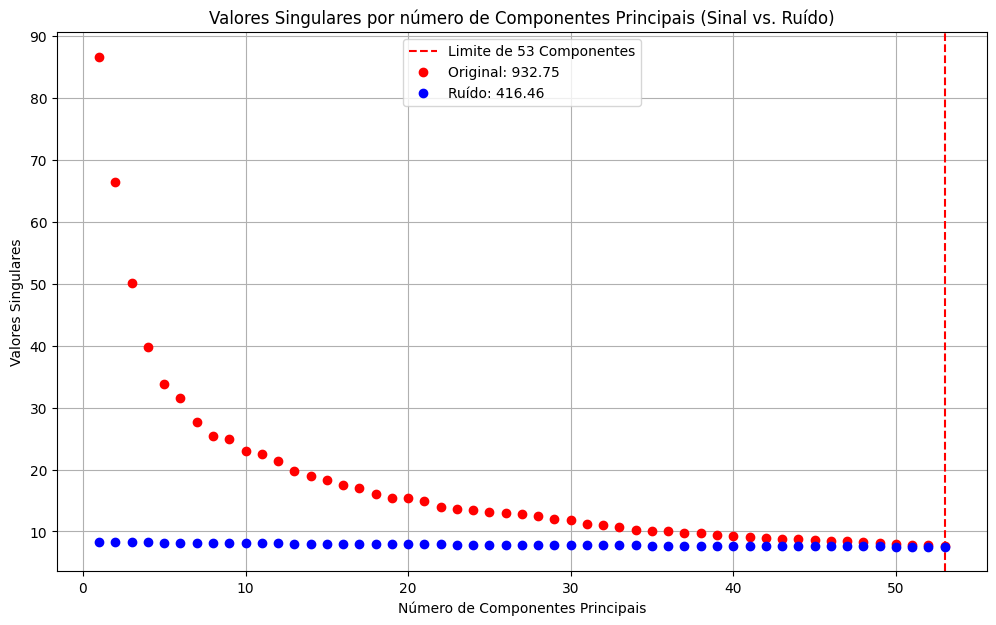

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA, KernelPCA
from skimage.util import random_noise

olivetti_faces = fetch_olivetti_faces(data_home='./scikit_learn_data')
faces_array = olivetti_faces.data
faces_float = faces_array.astype(np.float32)

noisy_data = random_noise(faces_float, mode='gaussian')
noise_array = noisy_data - faces_float

pca_full = PCA()

print("\nAnalisando o array de RUÍDO...")
pca_full.fit(noise_array)

singular_values_noise_53 = pca_full.singular_values_[:53]
cumulative_values_noise_53 = np.sum(singular_values_noise_53)

#print(f"Valores Singulares (primeiros 53) no ruído:\n {singular_values_noise_53}")
print(f"SOMA ACUMULADA dos Valores Singulares dos 53 primeiros CP (Ruído): {cumulative_values_noise_53:.4f}")

print("\nAnalisando o array ORIGINAL...")
pca_full.fit(faces_float)

singular_values_original_53 = pca_full.singular_values_[:53]
cumulative_values_original_53 = np.sum(singular_values_original_53)

#print(f"Valores Singulares (primeiros 53) no original:\n {singular_values_original_53}")
print(f"SOMA ACUMULADA dos Valores Singulares dos 53 primeiros CP (Original): {cumulative_values_original_53:.4f}")

print("\nPorcentagem da imagem com ruído pela imagem original: ", cumulative_values_noise_53 / cumulative_values_original_53)

plt.figure(figsize=(12, 7))

plt.axvline(53, color='red', linestyle='--', label='Limite de 53 Componentes')

plt.plot(range(1, 54), singular_values_original_53, 'ro', label=f'Original: {cumulative_values_original_53:.2f}')
plt.plot(range(1, 54), singular_values_noise_53, 'bo', label=f'Ruído: {cumulative_values_noise_53:.2f}')


plt.title('Valores Singulares por número de Componentes Principais (Sinal vs. Ruído)')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Valores Singulares')
plt.legend()
plt.grid(True)
plt.show()


Analisando o array de RUÍDO...
SOMA ACUMULADA da variância dos 148 primeiros CP (Ruído): 3.8037

Analisando o array ORIGINAL...
SOMA ACUMULADA da variância dos 148 primeiros CP (Original): 14.1306

Porcentagem da imagem com ruído pela imagem original:  0.26917958245121626


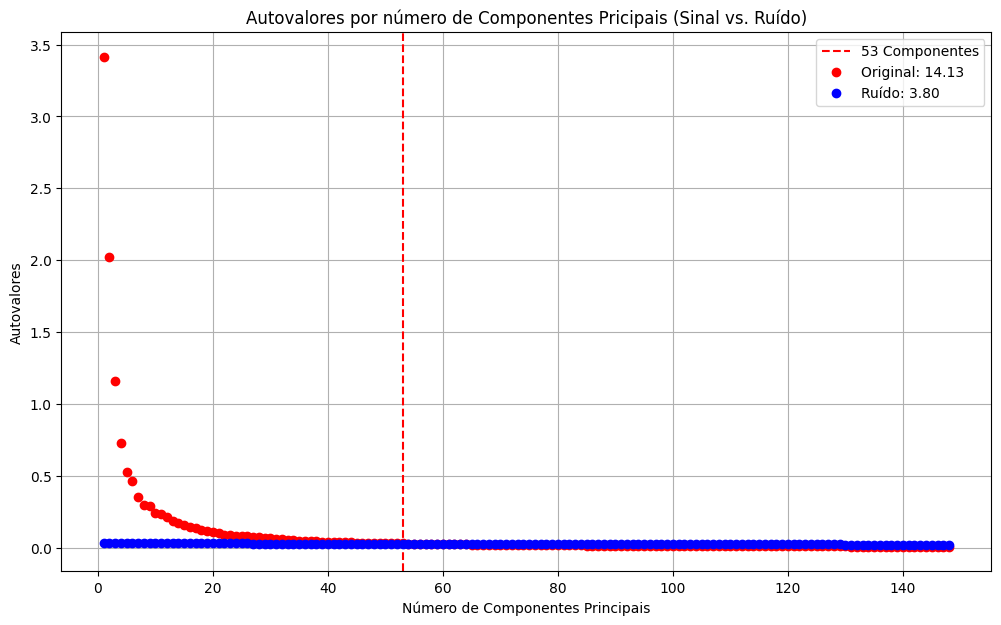

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA, KernelPCA
from skimage.util import random_noise

olivetti_faces = fetch_olivetti_faces(data_home='./scikit_learn_data')
faces_array = olivetti_faces.data
faces_float = faces_array.astype(np.float32)

noisy_data = random_noise(faces_float, mode='gaussian')
noise_array = noisy_data - faces_float

kpca_full = KernelPCA(kernel='rbf', alpha=0.0000212, gamma=0.000239)

print("\nAnalisando o array de RUÍDO...")
kpca_full.fit(noise_array)
#singular_values_noise_148 = np.cumsum(kpca_full.eigenvalues_[:148]) / np.sum(kpca_full.eigenvalues_)
singular_values_noise_148 = kpca_full.eigenvalues_[:148]
cumulative_values_noise_148 = np.sum(singular_values_noise_148[:148])
print(f"SOMA ACUMULADA da variância dos 148 primeiros CP (Ruído): {cumulative_values_noise_148:.4f}")


print("\nAnalisando o array ORIGINAL...")
kpca_full.fit(faces_float)
#Gráfico de energia
#singular_values_original_148 = np.cumsum(kpca_full.eigenvalues_[:148]) / np.sum(kpca_full.eigenvalues_)
singular_values_original_148 = kpca_full.eigenvalues_[:148]
cumulative_values_original_148 = np.sum(singular_values_original_148[:148])
print(f"SOMA ACUMULADA da variância dos 148 primeiros CP (Original): {cumulative_values_original_148:.4f}")

print("\nPorcentagem da imagem com ruído pela imagem original: ", cumulative_values_noise_148 / cumulative_values_original_148)

plt.figure(figsize=(12, 7))

plt.axvline(x=53, color='red', linestyle='--', label='53 Componentes')

plt.plot(range(1, 149), singular_values_original_148, 'ro', label=f'Original: {cumulative_values_original_148:.2f}')
plt.plot(range(1, 149), singular_values_noise_148, 'bo', label=f'Ruído: {cumulative_values_noise_148:.2f}')


plt.title('Autovalores por número de Componentes Pricipais (Sinal vs. Ruído)')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Autovalores')
plt.legend()
plt.grid(True)
plt.show()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to ./scikit_learn_data

Analisando o array de RUÍDO...
SOMA ACUMULADA da variância dos 53 primeiros CP (Ruído): 1.5508

Analisando o array ORIGINAL...
SOMA ACUMULADA da variância dos 53 primeiros CP (Original): 12.8371

Porcentagem da imagem com ruído pela imagem original:  0.12080713446458108


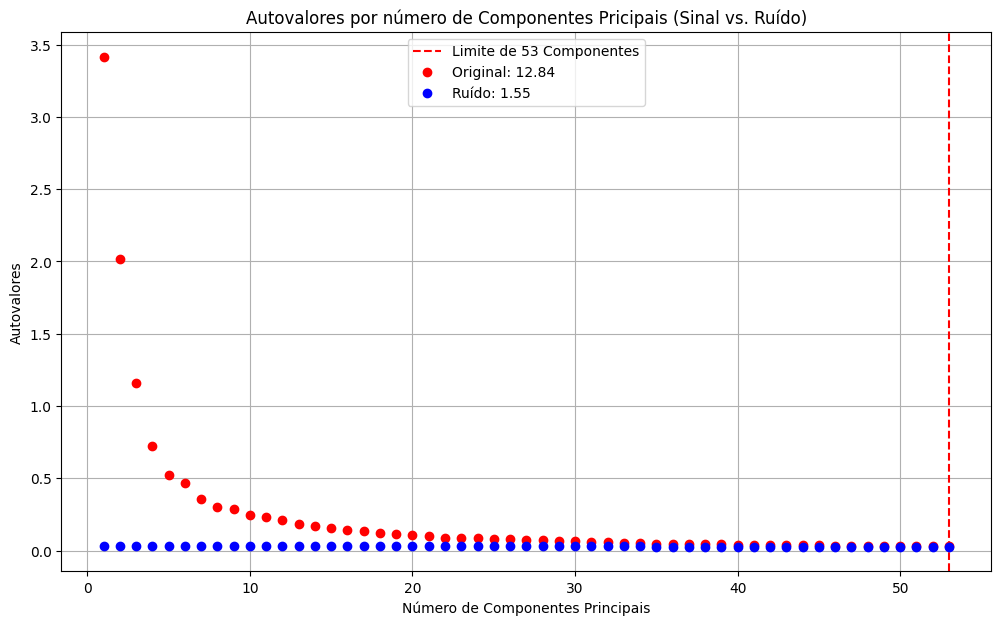

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA, KernelPCA
from skimage.util import random_noise

olivetti_faces = fetch_olivetti_faces(data_home='./scikit_learn_data')
faces_array = olivetti_faces.data
faces_float = faces_array.astype(np.float32)

noisy_data = random_noise(faces_float, mode='gaussian')
noise_array = noisy_data - faces_float

kpca_full = KernelPCA(kernel='rbf', alpha=0.0000212, gamma=0.000239)

print("\nAnalisando o array de RUÍDO...")
kpca_full.fit(noise_array)

singular_values_noise_53 = kpca_full.eigenvalues_[:53]
cumulative_values_noise_53 = np.sum(singular_values_noise_53)
print(f"SOMA ACUMULADA da variância dos 53 primeiros CP (Ruído): {cumulative_values_noise_53:.4f}")


print("\nAnalisando o array ORIGINAL...")
kpca_full.fit(faces_float)

singular_values_original_53 = kpca_full.eigenvalues_[:53]
cumulative_values_original_53 = np.sum(singular_values_original_53)
print(f"SOMA ACUMULADA da variância dos 53 primeiros CP (Original): {cumulative_values_original_53:.4f}")

print("\nPorcentagem da imagem com ruído pela imagem original: ",
      cumulative_values_noise_53 / cumulative_values_original_53)

plt.figure(figsize=(12, 7))

plt.axvline(x=53, color='red', linestyle='--', label='Limite de 53 Componentes')

plt.plot(range(1, 54), singular_values_original_53, 'ro',
         label=f'Original: {cumulative_values_original_53:.2f}')
plt.plot(range(1, 54), singular_values_noise_53, 'bo',
         label=f'Ruído: {cumulative_values_noise_53:.2f}')

plt.title('Autovalores por número de Componentes Pricipais (Sinal vs. Ruído)')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Autovalores')
plt.legend()
plt.grid(True)
plt.show()


Para alinhar a escala com o Kernel PCA (que trabalha diretamente com a matriz de covariância/kernel e retorna autovalores), precisamos aplicar a fórmula que conecta os dois mundos.A relação exata é:

$$\text{Autovalor} (\lambda) = \frac{\text{Valor Singular} (\sigma)^2}{n - 1}$$

Onde $n$ é o número de amostras (imagens), que no caso do Olivetti Faces é 400.


Analisando o array de RUÍDO...
SOMA ACUMULADA dos Autovalores (Variância) dos 53 primeiros CP (Ruído): 8.2357

Analisando o array ORIGINAL...
SOMA ACUMULADA dos Autovalores (Variância) dos 53 primeiros CP (Original): 69.5874

Razão Ruído/Sinal (baseada em autovalores): 0.1184


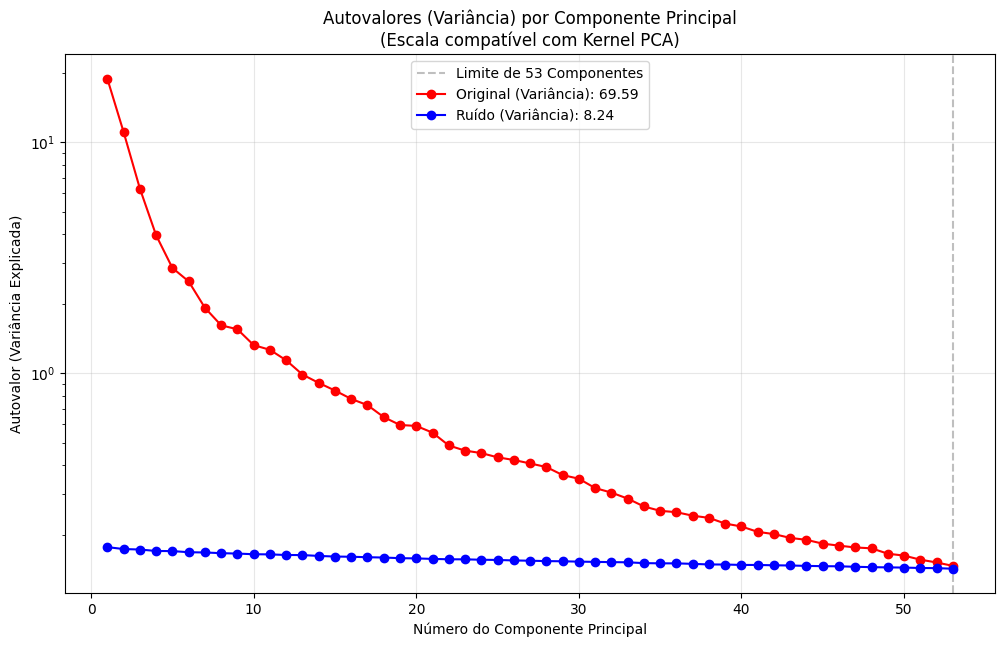

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from skimage.util import random_noise
from skimage import data, transform
import sys

# --- 1. Carregamento e Preparação ---
try:
    olivetti_faces = fetch_olivetti_faces(data_home='./scikit_learn_data')
    faces_array = olivetti_faces.data
except Exception:
    # Fallback caso falhe o download
    print("Usando dados sintéticos (fallback)...")
    img = transform.resize(data.camera(), (64, 64))
    faces_array = np.array([img.flatten() for _ in range(400)])
    faces_array += np.random.normal(0, 0.05, faces_array.shape)

faces_float = faces_array.astype(np.float32)

# Obter número de amostras (n) para a fórmula
n_samples = faces_float.shape[0]

# Gerar ruído e isolar
noisy_data = random_noise(faces_float, mode='gaussian', var=0.01) # Defini var explicita para controle
noise_array = noisy_data - faces_float

pca_full = PCA()

# --- 2. Análise do RUÍDO ---
print("\nAnalisando o array de RUÍDO...")
pca_full.fit(noise_array)

singular_values_noise = pca_full.singular_values_[:53]

# CONVERSÃO: Singular Value -> Eigenvalue (Variância)
eigenvalues_noise_53 = (singular_values_noise ** 2) / (n_samples - 1)
cumulative_variance_noise = np.sum(eigenvalues_noise_53)

print(f"SOMA ACUMULADA dos Autovalores (Variância) dos 53 primeiros CP (Ruído): {cumulative_variance_noise:.4f}")


# --- 3. Análise do ORIGINAL ---
print("\nAnalisando o array ORIGINAL...")
pca_full.fit(faces_float)

singular_values_original = pca_full.singular_values_[:53]

# CONVERSÃO: Singular Value -> Eigenvalue (Variância)
eigenvalues_original_53 = (singular_values_original ** 2) / (n_samples - 1)
cumulative_variance_original = np.sum(eigenvalues_original_53)

print(f"SOMA ACUMULADA dos Autovalores (Variância) dos 53 primeiros CP (Original): {cumulative_variance_original:.4f}")


# --- 4. Comparação ---
ratio = cumulative_variance_noise / cumulative_variance_original
print(f"\nRazão Ruído/Sinal (baseada em autovalores): {ratio:.4f}")

# --- 5. Plotagem ---
plt.figure(figsize=(12, 7))

# Linha de corte
plt.axvline(53, color='gray', linestyle='--', alpha=0.5, label='Limite de 53 Componentes')

# Plotando AUTOVALORES (Eigenvalues)
plt.plot(range(1, 54), eigenvalues_original_53, 'ro-', label=f'Original (Variância): {cumulative_variance_original:.2f}')
plt.plot(range(1, 54), eigenvalues_noise_53, 'bo-', label=f'Ruído (Variância): {cumulative_variance_noise:.2f}')

plt.title('Autovalores (Variância) por Componente Principal\n(Escala compatível com Kernel PCA)')
plt.xlabel('Número do Componente Principal')
plt.ylabel('Autovalor (Variância Explicada)')
plt.legend()
plt.grid(True, alpha=0.3)

# Dica: Autovalores caem muito rápido, log scale ajuda a ver o ruído melhor
# Descomente a linha abaixo se quiser ver em escala logarítmica
plt.yscale('log')

plt.show()

Apesar do comportamento ser parecido nos dois casos, vou ajustar a escala do Kernel PCA para a comparação ficar justa:

Dataset Olivetti carregado.
Dados preparados. N=400

[1/2] Executando PCA Padrão...
[2/2] Executando Kernel PCA...


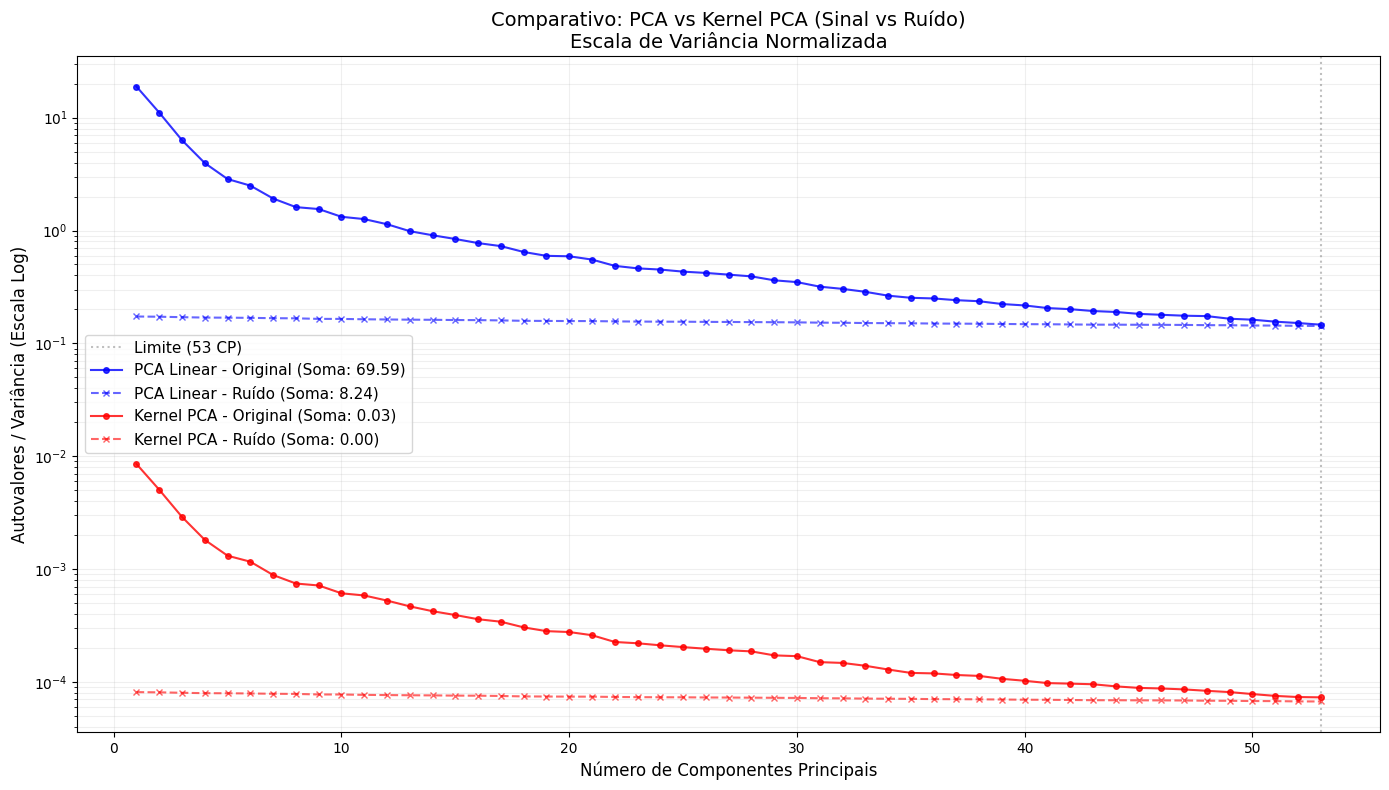

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA, KernelPCA
from skimage.util import random_noise
from skimage import data, transform
import sys

# --- 1. Carregar e Preparar Dados (Comum para ambos) ---
try:
    olivetti_faces = fetch_olivetti_faces(data_home='./scikit_learn_data')
    faces_array = olivetti_faces.data
    print("Dataset Olivetti carregado.")
except Exception:
    print("Usando dataset de fallback (Digits/Camera)...")
    from sklearn.datasets import load_digits
    faces_array = load_digits().data

faces_float = faces_array.astype(np.float32)
n_samples = faces_float.shape[0]

# --- 2. Gerar Ruído (Uma única vez para garantir comparação justa) ---
np.random.seed(42)
# Variância 0.01
noisy_data = random_noise(faces_float, mode='gaussian', var=0.01)
noise_array = noisy_data - faces_float

print(f"Dados preparados. N={n_samples}")

# ==========================================
# SOLUÇÃO A: PCA PADRÃO (Linear)
# ==========================================
print("\n[1/2] Executando PCA Padrão...")
pca = PCA()

# A.1 PCA no Original
pca.fit(faces_float)
pca_sing_orig = pca.singular_values_[:53]
# Conversão: Singular -> Variância (Autovalor)
pca_eig_orig = (pca_sing_orig ** 2) / (n_samples - 1)

# A.2 PCA no Ruído
pca.fit(noise_array)
pca_sing_noise = pca.singular_values_[:53]
pca_eig_noise = (pca_sing_noise ** 2) / (n_samples - 1)


# ==========================================
# SOLUÇÃO B: KERNEL PCA (RBF)
# ==========================================
print("[2/2] Executando Kernel PCA...")
# Seus hiperparâmetros exatos
kpca = KernelPCA(kernel='rbf', alpha=0.0000212, gamma=0.000239)

# B.1 KPCA no Original
kpca.fit(faces_float)
# Normalização: Dividir por N
kpca_eig_orig = kpca.eigenvalues_[:53] / n_samples

# B.2 KPCA no Ruído
kpca.fit(noise_array)
kpca_eig_noise = kpca.eigenvalues_[:53] / n_samples


# ==========================================
# PLOTAGEM UNIFICADA
# ==========================================
plt.figure(figsize=(14, 8))

# Linha de limite
plt.axvline(x=53, color='gray', linestyle=':', alpha=0.5, label='Limite (53 CP)')

# --- Plotar PCA (Azul) ---
plt.plot(range(1, 54), pca_eig_orig,
         color='blue', linestyle='-', marker='o', markersize=4, alpha=0.8,
         label=f'PCA Linear - Original (Soma: {np.sum(pca_eig_orig):.2f})')

plt.plot(range(1, 54), pca_eig_noise,
         color='blue', linestyle='--', marker='x', markersize=4, alpha=0.6,
         label=f'PCA Linear - Ruído (Soma: {np.sum(pca_eig_noise):.2f})')

# --- Plotar KPCA (Vermelho) ---
plt.plot(range(1, 54), kpca_eig_orig,
         color='red', linestyle='-', marker='o', markersize=4, alpha=0.8,
         label=f'Kernel PCA - Original (Soma: {np.sum(kpca_eig_orig):.2f})')

plt.plot(range(1, 54), kpca_eig_noise,
         color='red', linestyle='--', marker='x', markersize=4, alpha=0.6,
         label=f'Kernel PCA - Ruído (Soma: {np.sum(kpca_eig_noise):.2f})')

# Configurações do Gráfico
plt.title('Comparativo: PCA vs Kernel PCA (Sinal vs Ruído)\nEscala de Variância Normalizada', fontsize=14)
plt.xlabel('Número de Componentes Principais', fontsize=12)
plt.ylabel('Autovalores / Variância (Escala Log)', fontsize=12)

# Escala Log é essencial aqui para ver o ruído e o sinal juntos
plt.yscale('log')

plt.legend(fontsize=11)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()

plt.show()

Dataset Olivetti carregado.
Dados preparados. N=400

[1/2] Executando PCA Padrão...
[2/2] Executando Kernel PCA...


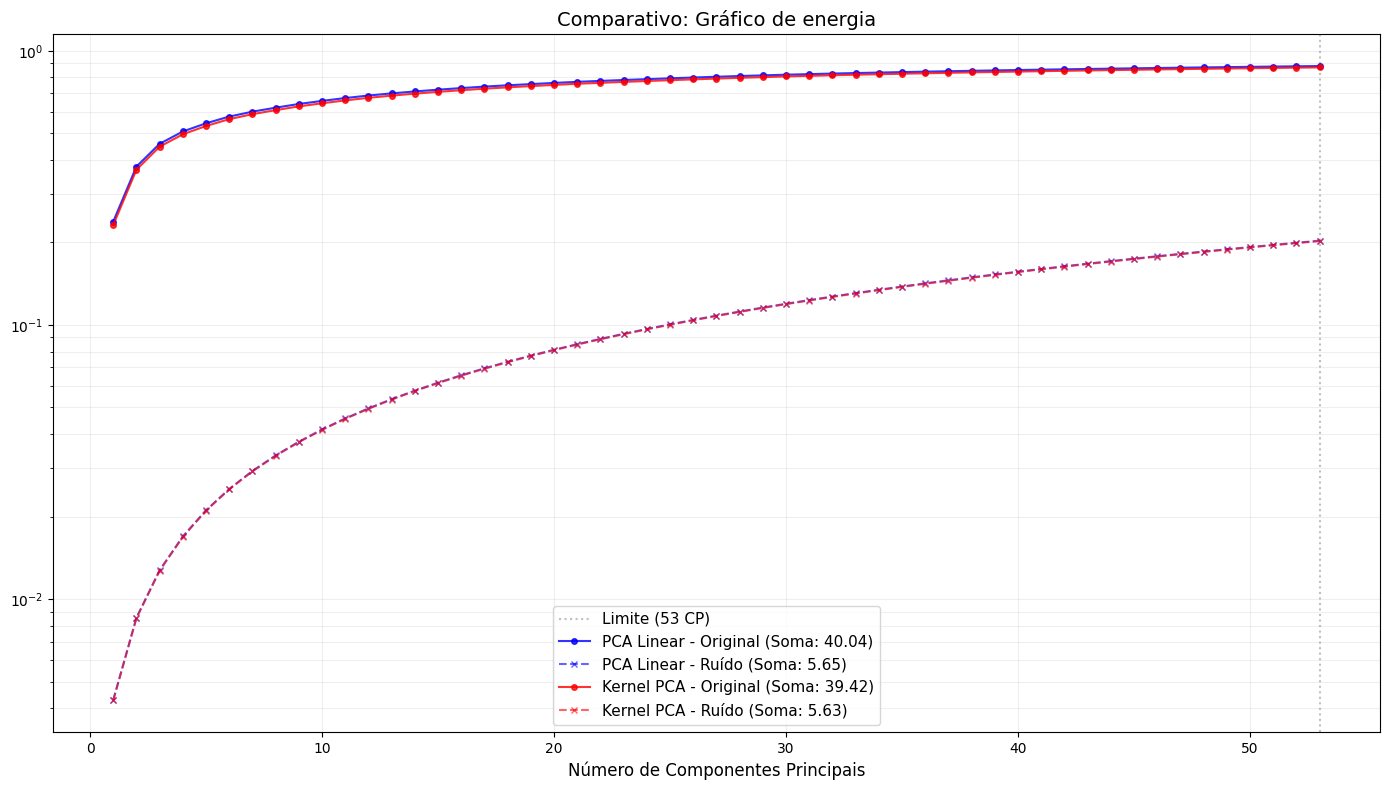

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA, KernelPCA
from skimage.util import random_noise
from skimage import data, transform
import sys

# --- 1. Carregar e Preparar Dados (Comum para ambos) ---
try:
    olivetti_faces = fetch_olivetti_faces(data_home='./scikit_learn_data')
    faces_array = olivetti_faces.data
    print("Dataset Olivetti carregado.")
except Exception:
    print("Usando dataset de fallback (Digits/Camera)...")
    from sklearn.datasets import load_digits
    faces_array = load_digits().data

faces_float = faces_array.astype(np.float32)
n_samples = faces_float.shape[0]

# --- 2. Gerar Ruído (Uma única vez para garantir comparação justa) ---
np.random.seed(42)
# Variância 0.01
noisy_data = random_noise(faces_float, mode='gaussian', var=0.01)
noise_array = noisy_data - faces_float

print(f"Dados preparados. N={n_samples}")

# ==========================================
# SOLUÇÃO A: PCA PADRÃO (Linear)
# ==========================================
print("\n[1/2] Executando PCA Padrão...")
pca = PCA()

# A.1 PCA no Original
pca.fit(faces_float)
#pca_sing_orig = pca.singular_values_[:53]
# Conversão: Singular -> Variância (Autovalor)
pca_eig_orig = np.cumsum(pca.singular_values_[:53]**2) / np.sum(pca.singular_values_**2)

# A.2 PCA no Ruído
pca.fit(noise_array)
#pca_sing_noise = pca.singular_values_[:53]
#pca_eig_noise = (pca_sing_noise ** 2) / (n_samples - 1)
pca_eig_noise = np.cumsum(pca.singular_values_[:53]**2) / np.sum(pca.singular_values_**2)


# ==========================================
# SOLUÇÃO B: KERNEL PCA (Polinomial)
# ==========================================
print("[2/2] Executando Kernel PCA...")
# Seus hiperparâmetros exatos
kpca = KernelPCA(kernel='rbf', alpha=0.0000212, gamma=0.000239)

# B.1 KPCA no Original
kpca.fit(faces_float)
# Normalização: Dividir por N
kpca_eig_orig = np.cumsum(kpca.eigenvalues_[:53]) / np.sum(kpca.eigenvalues_)

# B.2 KPCA no Ruído
kpca.fit(noise_array)
kpca_eig_noise = np.cumsum(kpca.eigenvalues_[:53]) / np.sum(kpca.eigenvalues_)


# ==========================================
# PLOTAGEM UNIFICADA
# ==========================================
plt.figure(figsize=(14, 8))

# Linha de limite
plt.axvline(x=53, color='gray', linestyle=':', alpha=0.5, label='Limite (53 CP)')

# --- Plotar PCA (Azul) ---
plt.plot(range(1, 54), pca_eig_orig,
         color='blue', linestyle='-', marker='o', markersize=4, alpha=0.8,
         label=f'PCA Linear - Original (Soma: {np.sum(pca_eig_orig):.2f})')

plt.plot(range(1, 54), pca_eig_noise,
         color='blue', linestyle='--', marker='x', markersize=4, alpha=0.6,
         label=f'PCA Linear - Ruído (Soma: {np.sum(pca_eig_noise):.2f})')

# --- Plotar KPCA (Vermelho) ---
plt.plot(range(1, 54), kpca_eig_orig,
         color='red', linestyle='-', marker='o', markersize=4, alpha=0.8,
         label=f'Kernel PCA - Original (Soma: {np.sum(kpca_eig_orig):.2f})')

plt.plot(range(1, 54), kpca_eig_noise,
         color='red', linestyle='--', marker='x', markersize=4, alpha=0.6,
         label=f'Kernel PCA - Ruído (Soma: {np.sum(kpca_eig_noise):.2f})')

# Configurações do Gráfico
plt.title('Comparativo: Gráfico de energia', fontsize=14)
plt.xlabel('Número de Componentes Principais', fontsize=12)
plt.ylabel('', fontsize=12)

# Escala Log é essencial aqui para ver o ruído e o sinal juntos
plt.yscale('log')

plt.legend(fontsize=11)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()

plt.show()

# Próximas ações